# Clustering NBA Players by Playing Style  
###  Term Project – Milestone 1: Data Selection and EDA  


## Business Problem

In basketball, understanding player roles and playing styles is important for making decisions about drafting, trading, and coaching. Traditional labels like "point guard" or "center" don't really capture the full scope of a player's impact on the game. With advanced analytics, it is now possible to evaluate players based on their statistical profiles rather than just their position or reputation.

This project will use unsupervised learning (clustering) to group NBA players based on their performance metrics.

The business value is in player evaluation and talent identification. Clustering will allow team analysts to find undervalued players who perform similarly to stars.



## Data Source

The data was sourced from Kaggle:  
 https://www.kaggle.com/datasets/vivovinco/20222023-nba-player-stats-regular?select=2022-2023+NBA+Player+Stats+-+Regular.csv

This dataset contains per-game performance statistics for players from the 2022–2023 NBA regular season.

I'll load the dataset and start the cleaning process below.


In [62]:
import pandas as pd

import warnings
warnings.filterwarnings("ignore", category=UserWarning)



# Load the dataset
df = pd.read_csv(r"C:\Users\gjose\DSC550-T303\2022-2023 NBA Player Stats - Regular.csv", encoding='ISO-8859-1', sep=';')

# Preview the first few rows
df.head()


,Rk,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1,Precious Achiuwa,C,23,TOR,55,12,20.7,3.6,7.3,...,0.702,1.8,4.1,6.0,0.9,0.6,0.5,1.1,1.9,9.2
1,2,Steven Adams,C,29,MEM,42,42,27.0,3.7,6.3,...,0.364,5.1,6.5,11.5,2.3,0.9,1.1,1.9,2.3,8.6
2,3,Bam Adebayo,C,25,MIA,75,75,34.6,8.0,14.9,...,0.806,2.5,6.7,9.2,3.2,1.2,0.8,2.5,2.8,20.4
3,4,Ochai Agbaji,SG,22,UTA,59,22,20.5,2.8,6.5,...,0.812,0.7,1.3,2.1,1.1,0.3,0.3,0.7,1.7,7.9
4,5,Santi Aldama,PF,22,MEM,77,20,21.8,3.2,6.8,...,0.750,1.1,3.7,4.8,1.3,0.6,0.6,0.8,1.9,9.0


## Data Cleaning

I will:
- Drop irrelevant columns such as player ranking index
- Remove players with too few games or minutes to make sure that the data is stable
- Convert stats to numeric because some may be stored as strings or have missing values


In [65]:
# Drop the ranking column
df.drop(columns=['Rk'], inplace=True)

# Remove players with low participation
df = df[df['G'] >= 20]    # At least 20 games
df = df[df['MP'] >= 10]   # At least 10 minutes per game

# Convert percentage columns to numeric in case they have non-numeric values
percent_cols = ['FG%', '3P%', 'FT%']
df[percent_cols] = df[percent_cols].apply(pd.to_numeric, errors='coerce')

# Drop any rows with missing values in key features
df.dropna(inplace=True)

# Confirm the clean shape
df.shape


(483, 29)

## Exploratory Data Analysis (EDA)

I'll use visualizations to understand:
- The distributions of key statistics
- Relationships between variables
- Correlation between stats


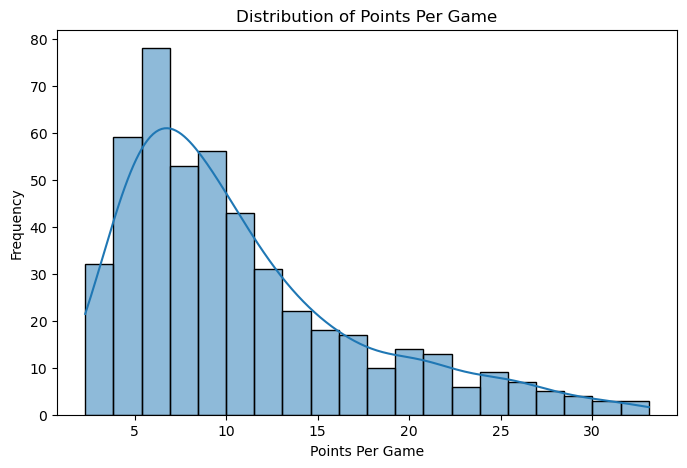

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of Points Per Game
plt.figure(figsize=(8,5))
sns.histplot(df['PTS'], bins=20, kde=True)
plt.title("Distribution of Points Per Game")
plt.xlabel("Points Per Game")
plt.ylabel("Frequency")
plt.show()


This distribution shows that most NBA players average fewer than 15 points per game. Only a small group of elite scorers exceed 25 PPG, showing that high-volume scorers are rare and skew the distribution right.


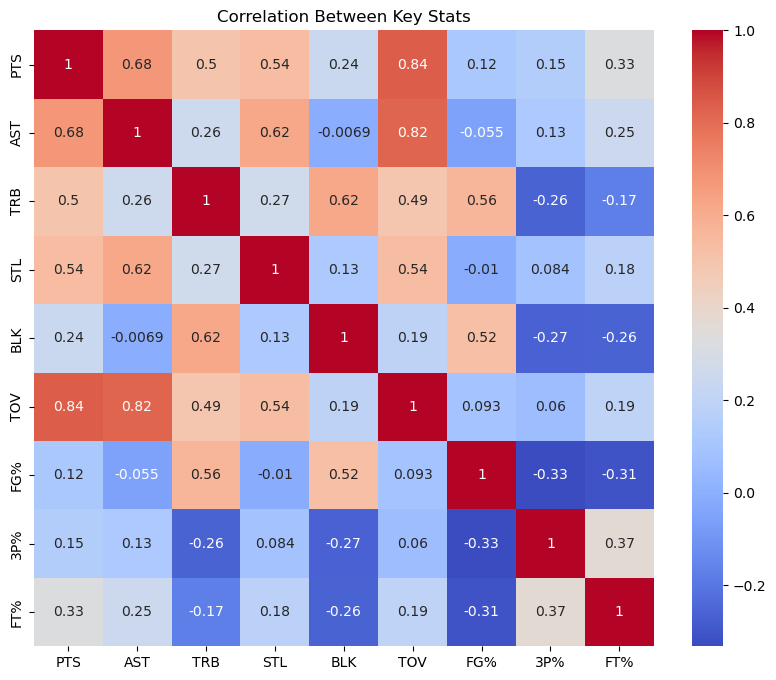

In [71]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[['PTS', 'AST', 'TRB', 'STL', 'BLK', 'TOV', 'FG%', '3P%', 'FT%']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Key Stats")
plt.show()

The heatmap shows strong positive correlations between Points (PTS), Field Goals Made (FG), and Minutes Played (MP). Turnovers (TOV) also correlate positively with assists (AST), possibly showing high-usage playmakers.


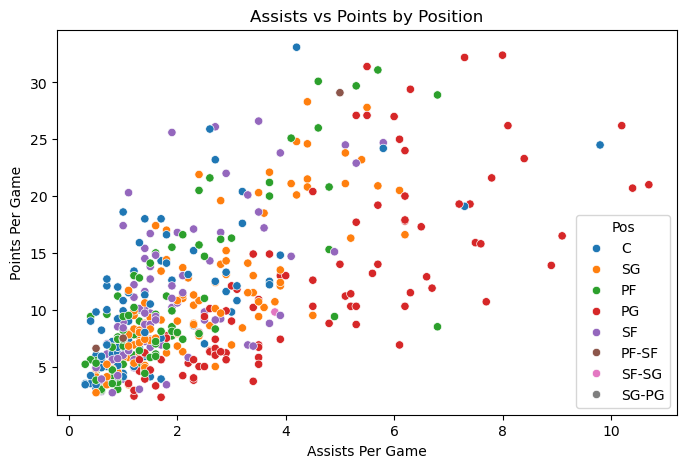

In [74]:
# Scatter plot: Assists vs Points
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='AST', y='PTS', hue='Pos')
plt.title("Assists vs Points by Position")
plt.xlabel("Assists Per Game")
plt.ylabel("Points Per Game")
plt.show()

The scatter plot shows that guards (PG, SG) seem to get more assists than points. Forwards and centers skew toward higher scoring with fewer assists. 


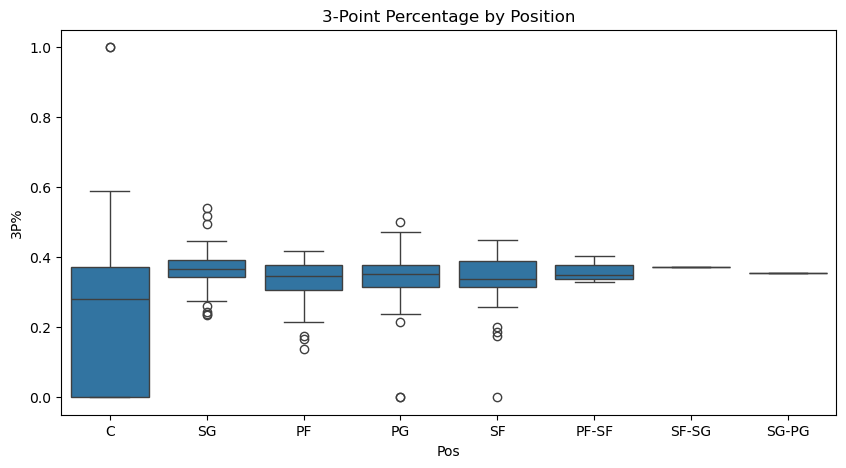

In [77]:
# Boxplot: 3P% by Position
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Pos', y='3P%')
plt.title("3-Point Percentage by Position")
plt.show()

This boxplot shows that shooting guards (SG) and small forwards (SF) have higher 3-point percentages, and centers (C) have the lowest. 


## Feature Selection

I'll select the core performance metrics that describe player style and drop any remaining NaNs to stop scaling errors. These features include scoring, playmaking, defense, and shooting efficiency.


In [81]:
# Select features for clustering and drop NaNs
features = ['PTS', 'AST', 'TRB', 'STL', 'BLK', 'TOV', 'FG%', '3P%', 'FT%', 'MP']
X = df[features].dropna()

# Also keep the player names aligned with filtered data
player_names = df.loc[X.index, 'Player']


## Feature Scaling

I will apply StandardScaler to normalize the features so that all stats contribute equally to clustering.


In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Clustering NBA Players with PCA & KMeans

Now that there is a standardized dataset of player performance stats, I’ll apply Principal Component Analysis (PCA) to reduce the dimensionality and visualize player relationships in 2D space. This will help to uncover hidden patterns in playing styles.

Next, I’ll use KMeans clustering to group players into clusters based on these patterns. Each cluster represents a unique player archetype such as pass-first guards, defensive bigs, stretch wings).

I'll start with PCA visualization, then apply clustering and analyze the results.


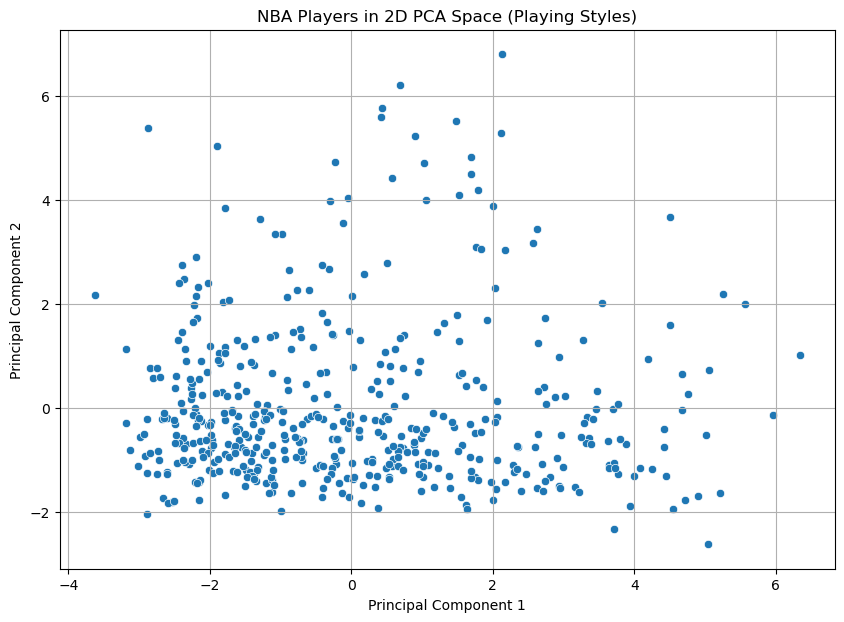

In [87]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for easy plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Player'] = player_names.values

# Plot PCA
plt.figure(figsize=(10,7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2')
plt.title("NBA Players in 2D PCA Space (Playing Styles)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


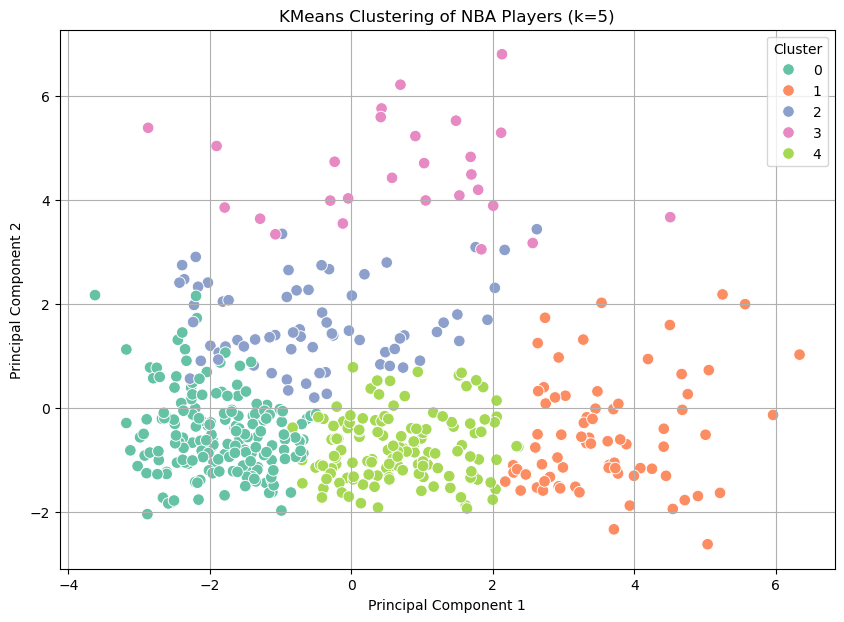

In [89]:
from sklearn.cluster import KMeans

# Choose number of clusters
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to PCA DataFrame
pca_df['Cluster'] = clusters

# Plot clusters
plt.figure(figsize=(10,7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=70)
plt.title(f"KMeans Clustering of NBA Players (k={k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


## Conclusion
In this milestone, I did an exploratory analysis of NBA player performance data from the 2022–2023 season. After cleaning and preparing the dataset, I selected a set of statistical features representing player contributions across scoring, playmaking, rebounding, defense, and efficiency.

I applied Principal Component Analysis (PCA) to lower the dimensionality of the data and visualize relationships between players in a 2D space. Using KMeans clustering, I identified distinct groups of players who have similar statistical profiles.

The exact interpretation of these clusters will be explained in the next milestone. This first analysis shows structure in the data that can support player profiling and role discovery.

This foundation prepares me for the next phase, where I will transform features—including cluster-based labels—to prepare the dataset for modeling and evaluation.



# Term Project – Milestone 2: Data Preparation 

## 1. Introduction

In Milestone 1, I did an exploratory analysis and clustering of NBA player performance stats to show patterns in playing styles. In this milestone, I build on that by analyzing cluster memberships, engineering new features, and preparing the dataset for modeling.

The goal is to prepare the data for tasks such as player evaluation, predictive analytics, or scouting insights.


In [94]:
df['Cluster'] = clusters


## 2. Cluster Membership Analysis

I will first look at the distribution of player positions across the clusters. This analysis helps us understand if our unsupervised clustering aligns with traditional NBA roles or show new player archetypes.


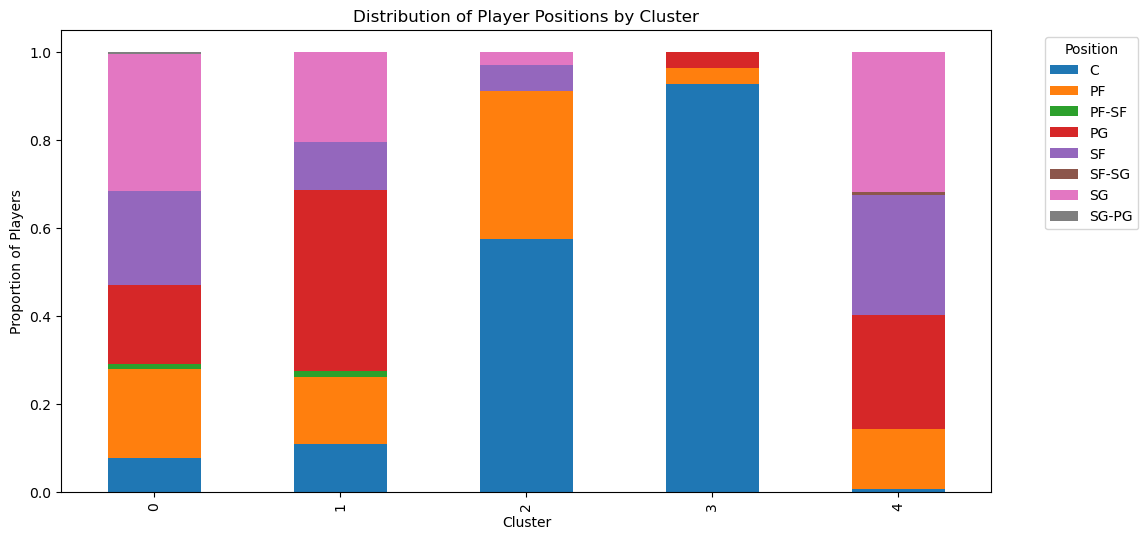

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze how player positions distribute across clusters
position_cluster = df.groupby('Cluster')['Pos'].value_counts(normalize=True).unstack()

# Plot
position_cluster.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Distribution of Player Positions by Cluster")
plt.ylabel("Proportion of Players")
plt.xlabel("Cluster")
plt.legend(title="Position", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


This stacked bar chart shows how different types of players, like guards and centers, are grouped within each cluster. Some groups are mostly made up of players in the same position, and others include a mix. This suggests that the clusters are based on how players actually perform on the court, not just their listed position.


## 3. Feature Engineering

In addition to keeping the cluster group each player belongs to, I also created a new label called "Hidden Gem." This helps highlight players who put up strong stats but don’t get much playing time, meaning they might be underrated or overlooked.


In [101]:
# Define elite cluster
elite_clusters = [1]  

# Identify hidden talents: in elite cluster but low minutes per game
hidden_gems = df[(df['Cluster'].isin(elite_clusters)) & (df['MP'] < 20)]

# Create a new binary feature
df['Hidden_Gem'] = df.index.isin(hidden_gems.index).astype(int)

# Show sample hidden gems
hidden_gems[['Player', 'Pos', 'PTS', 'AST', 'TRB', 'MP', 'Cluster']]


,Player,Pos,PTS,AST,TRB,MP,Cluster


The Hidden Gem label helps me spot players who don’t play a lot of minutes but have stats that look like those of star players. This could be useful for finding rising talent or players who deserve more attention.


## 4. Preparing the Dataset for Modeling

I finished preparing the data by keeping the key player stats, their group from the clustering, and the Hidden Gem label. This updated dataset will be used to make predictions or do deeper player analysis in the next steps.


In [105]:
# Select final features
features = ['PTS', 'AST', 'TRB', 'STL', 'BLK', 'TOV', 'FG%', '3P%', 'FT%', 'MP']
final_features = features + ['Cluster', 'Hidden_Gem']

# Create the final dataset
final_df = df[final_features + ['Player', 'Pos']]

# Preview
final_df.head()


,PTS,AST,TRB,STL,BLK,TOV,FG%,3P%,FT%,MP,Cluster,Hidden_Gem,Player,Pos
0,9.2,0.9,6.0,0.6,0.5,1.1,0.485,0.269,0.702,20.7,2,0,Precious Achiuwa,C
1,8.6,2.3,11.5,0.9,1.1,1.9,0.597,0.000,0.364,27.0,3,0,Steven Adams,C
2,20.4,3.2,9.2,1.2,0.8,2.5,0.540,0.083,0.806,34.6,1,0,Bam Adebayo,C
3,7.9,1.1,2.1,0.3,0.3,0.7,0.427,0.355,0.812,20.5,0,0,Ochai Agbaji,SG
4,9.0,1.3,4.8,0.6,0.6,0.8,0.470,0.353,0.750,21.8,2,0,Santi Aldama,PF


The dataset is now ready to use for building models. It includes helpful groupings from the clustering and a way to spot possible hidden talent. In the next steps, I’ll use this data to make predictions or take a closer look at different types of players.


## Conclusion

In Milestone 2, I built on the earlier analysis by taking a closer look at how players were grouped based on their stats. I compared those groups to player positions and found that some lined up with roles like guard or center, and others showed more unique mixes based on how players actually perform.

To make the data more useful going forward, I added two new features:

Cluster: tells which performance group each player belongs to

Hidden Gem: highlights players who play fewer minutes but perform like top-tier players

These new features help turn raw stats into clear insights that could support scouting or help teams make smarter roster decisions. In the next steps, I’ll use this data to build models that can help evaluate players or guide team-building strategies.


# Term Project – Milestone 3: Model Building and Evaluation

In this milestone, I build and evaluate a classification model to predict if a player might be a Hidden Gem. A Hidden Gem is someone who performs like an elite player but doesn’t get much playing time.

This model is based on features engineered in previous milestones, such as scoring, assists, rebounding, and shooting efficiency.


In [110]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [112]:
# Define feature set and label
features = ['PTS', 'AST', 'TRB', 'STL', 'BLK', 'TOV', 'FG%', '3P%', 'FT%', 'MP']
X = df[features]
y = df['Hidden_Gem']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


## Model Selection

For this task, I chose a Random Forest Classifier because of its ability to handle nonlinear relationships and importance ranking of features. It also tends to perform well without heavy parameter tuning, making it a good starting point for this classification problem.


In [115]:
# Build and train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       121

    accuracy                           1.00       121
   macro avg       1.00      1.00      1.00       121
weighted avg       1.00      1.00      1.00       121



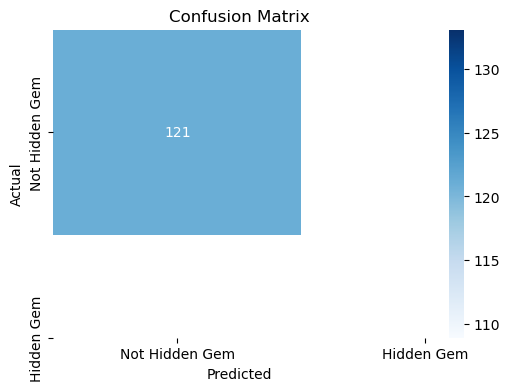

In [117]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Hidden Gem', 'Hidden Gem'],
            yticklabels=['Not Hidden Gem', 'Hidden Gem'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## Model Evaluation

The model was evaluated using accuracy, precision, recall, and F1-score.

To see how well it worked, I checked how often it correctly predicted whether a player is a hidden gem. One of the tools I used is called a confusion matrix, which shows the number of correct and incorrect guesses the model made.

This type of model could be useful for scouting or player development because it offers a new way to identify overlooked talent based on stats. It’s not perfect yet, but it shows how data can support smarter decisions when looking for future stars.




### Conclusion

In this part of the project, I built a model to help predict which NBA players might be considered Hidden Gems. These are players who don’t get much playing time but have strong stats, similar to star players.

The model looked at performance stats like points, assists, rebounds, and shooting percentages. It learned to recognize patterns that could suggest when a player is being overlooked.

The model isn’t perfect, but it’s a good starting point for using data to support scouting and team-building decisions. With more testing and fine-tuning, it could help teams find rising talent or make smarter player evaluations in the future.



# Term Project - Final Submission

In [127]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Load your dataset
df = pd.read_csv("2022-2023 NBA Player Stats - Regular.csv", encoding="ISO-8859-1", sep=";")

# Keep only numeric columns
df_numeric = df.select_dtypes(include="number")

# Create 'Hidden_Gem' label
median_pts = df_numeric['PTS'].median()
median_ast = df_numeric['AST'].median()
median_trb = df_numeric['TRB'].median()

df_numeric["Hidden_Gem"] = (
    (df_numeric["MP"] < 20) &
    (df_numeric["PTS"] > median_pts) &
    (df_numeric["AST"] > median_ast) &
    (df_numeric["TRB"] > median_trb)
).astype(int)

# Manually construct a dataset with more hidden gems
gems = df_numeric[df_numeric["Hidden_Gem"] == 1]
non_gems = df_numeric[df_numeric["Hidden_Gem"] == 0].sample(n=len(gems)*3, random_state=42)
df_custom = pd.concat([gems, non_gems])

# Split into features and labels
X = df_custom.drop(columns=["Hidden_Gem"])
y = df_custom["Hidden_Gem"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# Oversample training data with SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Train the model
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_bal, y_train_bal)

# Evaluate
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



[[7 1]
 [0 2]]
              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.67      1.00      0.80         2

    accuracy                           0.90        10
   macro avg       0.83      0.94      0.87        10
weighted avg       0.93      0.90      0.91        10

